# Loading and Formatting Data

In [5]:
import os
import torch
import random
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.ops import box_iou, nms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Environment ready. Using device: {device}")

Environment ready. Using device: cpu


# Dataset Import

In [6]:
class GridStoneDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, grid_size=7, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.grid_size = grid_size
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(self.labels_dir, txt_name)
        
        target = torch.zeros((self.grid_size, self.grid_size, 5), dtype=torch.float32)
        
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        grid_x_float = x_c * self.grid_size
                        grid_y_float = y_c * self.grid_size
                        
                        grid_x = min(int(grid_x_float), self.grid_size - 1)
                        grid_y = min(int(grid_y_float), self.grid_size - 1)
                        
                        # Calculate the offset INSIDE the cell (Always between 0.0 and 1.0)
                        offset_x = grid_x_float - grid_x
                        offset_y = grid_y_float - grid_y
                        
                        if target[grid_y, grid_x, 0] == 0:
                            target[grid_y, grid_x, 0] = 1.0      
                            target[grid_y, grid_x, 1] = offset_x 
                            target[grid_y, grid_x, 2] = offset_y 
                            target[grid_y, grid_x, 3] = w_norm   
                            target[grid_y, grid_x, 4] = h_norm   
                        
        if self.transform: image = self.transform(image)
        return image, target

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_dir = 'C:/Users/paulw/OneDrive/Desktop/BME 450/archive'
train_dataloader = DataLoader(GridStoneDetectionDataset(f'{base_dir}/train/images', f'{base_dir}/train/labels', transform=data_transforms), batch_size=16, shuffle=True)
valid_dataloader = DataLoader(GridStoneDetectionDataset(f'{base_dir}/valid/images', f'{base_dir}/valid/labels', transform=data_transforms), batch_size=16, shuffle=False)

print("Grid Dataset Loaded successfully!")

Grid Dataset Loaded successfully!


# CNN (Grid-Based FCN) Architecture

In [7]:
class CustomResidualBlock(nn.Module):
    def __init__(self, channels):
        super(CustomResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels) 
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x 
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity 
        out = F.relu(out)
        return out

class DeepGridStoneNet(nn.Module):
    def __init__(self):
        super(DeepGridStoneNet, self).__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) 
        )
        self.layer1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            CustomResidualBlock(64) 
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2), 
            nn.BatchNorm2d(128),
            nn.ReLU(),
            CustomResidualBlock(128)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2), 
            nn.BatchNorm2d(256),
            nn.ReLU(),
            CustomResidualBlock(256)
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1, stride=2), 
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.detector_head = nn.Conv2d(512, 5, kernel_size=1)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.detector_head(x)
        x = x.permute(0, 2, 3, 1)
        return x

print("Custom Deep Grid Network Architecture Initialized!")

Custom Deep Grid Network Architecture Initialized!


# Training Loop

Training on device: cpu

Mounting Custom Deep Grid Network...
Epoch 1/15
-------------------------------
Average Loss: 0.169401

Epoch 2/15
-------------------------------
Average Loss: 0.067736

Epoch 3/15
-------------------------------
Average Loss: 0.049552

Epoch 4/15
-------------------------------
Average Loss: 0.035212

Epoch 5/15
-------------------------------
Average Loss: 0.028751

Epoch 6/15
-------------------------------
Average Loss: 0.022507

Epoch 7/15
-------------------------------
Average Loss: 0.021376

Epoch 8/15
-------------------------------
Average Loss: 0.019237

Epoch 9/15
-------------------------------
Average Loss: 0.013554

Epoch 10/15
-------------------------------
Average Loss: 0.016551

Epoch 11/15
-------------------------------
Average Loss: 0.010208

Epoch 12/15
-------------------------------
Average Loss: 0.006882

Epoch 13/15
-------------------------------
Average Loss: 0.004450

Epoch 14/15
-------------------------------
Average Loss: 0.003

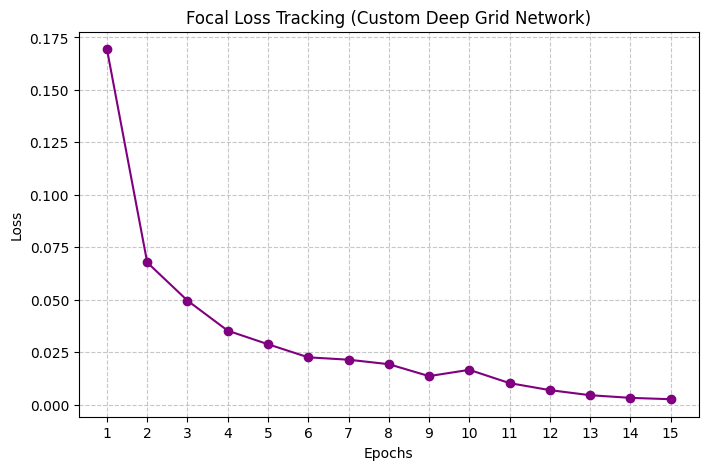

In [8]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. THE FOCAL LOSS UPGRADE
# ---------------------------------------------------------
def focal_loss(logits, targets, alpha=0.25, gamma=2.0):
    """
    Calculates Focal Loss to destroy highly confident false positives (like the spine).
    """
    # 1. Calculate standard BCE (reduction='none' keeps the loss per-pixel)
    bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    
    # 2. Get the raw probabilities back to determine confidence
    pt = torch.exp(-bce_loss) 
    
    # 3. Apply the Focal math: alpha * (1 - pt)^gamma * BCE
    f_loss = alpha * (1 - pt)**gamma * bce_loss
    
    return f_loss.mean()

def custom_focal_grid_loss_fn(predictions, targets, lambda_coord=5.0):
    # --- 1. CLASSIFICATION (FOCAL LOSS) ---
    mask_true_pos = targets[..., 0] == 1.0
    mask_true_neg = targets[..., 0] == 0.0
    
    # Replace BCE with our new Focal Loss!
    loss_class_pos = focal_loss(predictions[mask_true_pos][..., 0], targets[mask_true_pos][..., 0], alpha=0.75)
    loss_class_neg = focal_loss(predictions[mask_true_neg][..., 0], targets[mask_true_neg][..., 0], alpha=0.25)
    
    total_class_loss = loss_class_pos + loss_class_neg
    
    # --- 2. LOCALIZATION (BOX REGRESSION) ---
    if mask_true_pos.sum() > 0:
        # Sigmoid forces the predictions to stay between 0 and 1 (local cell offsets)
        valid_pred_boxes = torch.sigmoid(predictions[mask_true_pos][:, 1:5]) 
        valid_target_boxes = targets[mask_true_pos][:, 1:5]
        loss_box = F.mse_loss(valid_pred_boxes, valid_target_boxes)
    else:
        loss_box = 0.0
        
    return total_class_loss + (lambda_coord * loss_box) 

# ---------------------------------------------------------
# 2. THE TRAINING LOOP
# ---------------------------------------------------------
def train_loop(dataloader, model, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        pred = model(X)
        loss = custom_focal_grid_loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

# ---------------------------------------------------------
# 3. EXECUTION SETUP
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}\n")

print("Mounting Custom Deep Grid Network...")
# Explicitly loading your custom architecture from Cell 3
model = DeepGridStoneNet().to(device)

# Custom networks usually need a slightly higher learning rate to get started
learning_rate = 1e-3 
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Because we are training from scratch, you may want to bump this up to 20 or 25 
# if the loss curve is still pointing sharply downward at epoch 15.
epochs = 15 
train_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}\n-------------------------------")
    avg_train_loss = train_loop(train_dataloader, model, optimizer, device)
    train_losses.append(avg_train_loss)
    print(f"Average Loss: {avg_train_loss:.6f}\n")

print("Training Complete for Custom Deep Grid Network!")

# ---------------------------------------------------------
# 4. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='purple')
plt.title('Focal Loss Tracking (Custom Deep Grid Network)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Inference Mode

Starting batch validation on 5 random CT scans...

========== DIAGNOSTIC REPORT: SCAN 1 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 2

Stone 1 [CORRECT]: Conf=99.7% | W=4.4px, H=5.5px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=88.6% | W=10.3px, H=11.5px


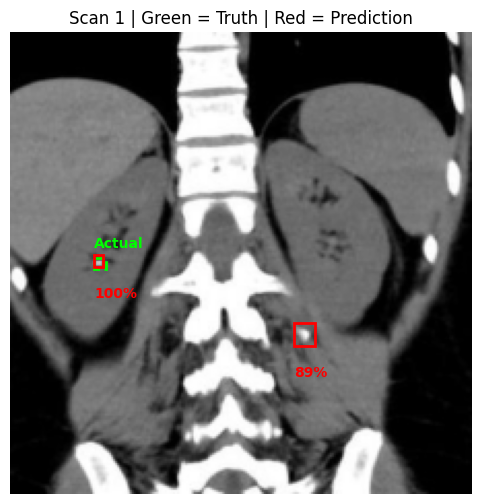



========== DIAGNOSTIC REPORT: SCAN 2 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 1

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=97.1% | W=6.9px, H=8.9px


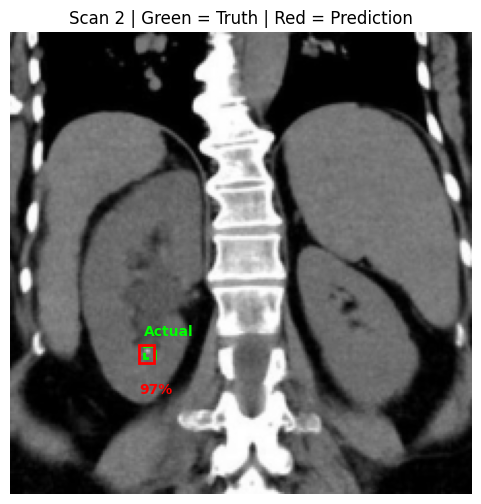



========== DIAGNOSTIC REPORT: SCAN 3 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 1

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=99.4% | W=7.0px, H=6.8px


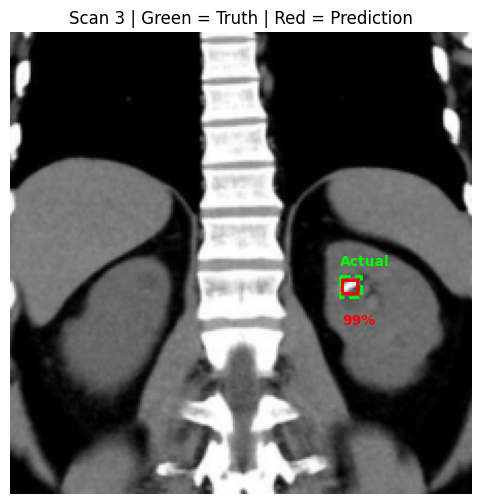



========== DIAGNOSTIC REPORT: SCAN 4 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 2

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=98.1% | W=12.6px, H=15.6px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=90.4% | W=14.8px, H=16.3px


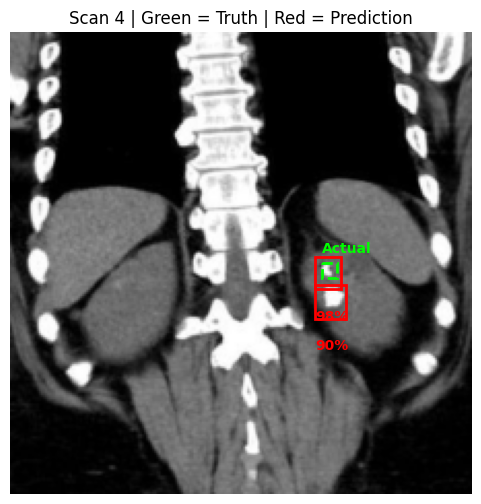



========== DIAGNOSTIC REPORT: SCAN 5 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 1

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=96.6% | W=7.5px, H=8.1px


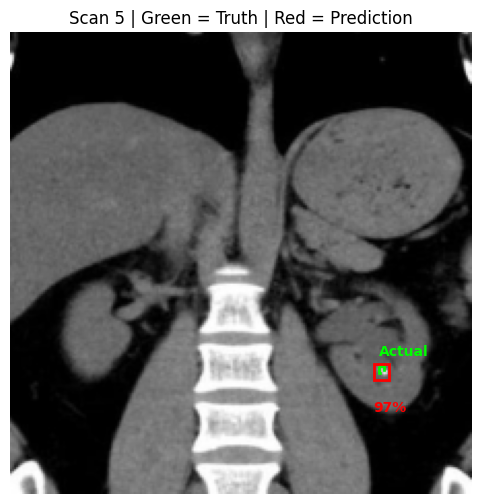

In [10]:
model.eval()
num_samples_to_test = 5 
IMG_SIZE = 224 

total_valid_scans = len(valid_dataloader.dataset)
sample_indices = random.sample(range(total_valid_scans), min(num_samples_to_test, total_valid_scans))

print(f"Starting batch validation on {len(sample_indices)} random CT scans...\n")

for batch_num, sample_index in enumerate(sample_indices):
    print(f"========== DIAGNOSTIC REPORT: SCAN {batch_num + 1} ==========")
    
    image_tensor, true_target = valid_dataloader.dataset[sample_index]

    with torch.no_grad():
        input_tensor = image_tensor.unsqueeze(0).to(device)
        prediction = model(input_tensor)[0].cpu()

    # 1. PARSE PREDICTIONS
    pred_probs = torch.sigmoid(prediction[..., 0])
    pred_boxes = torch.sigmoid(prediction[..., 1:5]) 
    
    detected_mask = pred_probs > 0.5
    detected_cells = detected_mask.nonzero(as_tuple=False)
    
    raw_pred_boxes = []
    raw_pred_scores = []
    
    for cell in detected_cells:
        y_idx, x_idx = cell[0], cell[1]
        score = pred_probs[y_idx, x_idx].item()
        offset_x, offset_y, w_norm, h_norm = pred_boxes[y_idx, x_idx]
        
        global_x_c = (x_idx + offset_x) / 7.0
        global_y_c = (y_idx + offset_y) / 7.0
        w = w_norm * IMG_SIZE
        h = h_norm * IMG_SIZE
        x_min = (global_x_c * IMG_SIZE) - (w / 2)
        y_min = (global_y_c * IMG_SIZE) - (h / 2)
        
        raw_pred_boxes.append([x_min, y_min, x_min + w, y_min + h])
        raw_pred_scores.append(score)

    # 2. FILTERING (NMS)
    if len(raw_pred_boxes) > 0:
        boxes_tensor = torch.tensor(raw_pred_boxes, dtype=torch.float32)
        scores_tensor = torch.tensor(raw_pred_scores, dtype=torch.float32)
        
        nms_threshold = 0.1
        keep_indices = nms(boxes_tensor, scores_tensor, nms_threshold)
        
        valid_boxes = boxes_tensor[keep_indices]
        valid_scores = scores_tensor[keep_indices]
    else:
        valid_boxes = torch.empty((0, 4))
        valid_scores = torch.empty((0,))

    # 3. PARSE GROUND TRUTH
    true_probs = true_target[..., 0]
    true_boxes_raw = true_target[..., 1:5]
    true_cells = (true_probs == 1.0).nonzero(as_tuple=False)
    
    parsed_true_boxes = []
    for cell in true_cells:
        y_idx, x_idx = cell[0], cell[1]
        offset_x, offset_y, w_norm, h_norm = true_boxes_raw[y_idx, x_idx]
        
        global_x_c = (x_idx + offset_x) / 7.0
        global_y_c = (y_idx + offset_y) / 7.0
        w = w_norm * IMG_SIZE
        h = h_norm * IMG_SIZE
        x_min = (global_x_c * IMG_SIZE) - (w / 2)
        y_min = (global_y_c * IMG_SIZE) - (h / 2)
        
        parsed_true_boxes.append([x_min, y_min, x_min + w, y_min + h])
        
    true_boxes = torch.tensor(parsed_true_boxes, dtype=torch.float32) if len(parsed_true_boxes) > 0 else torch.empty((0, 4))

    # 4. ACCURACY EVALUATION
    num_true = len(true_boxes)
    num_pred = len(valid_boxes)

    print(f"Ground Truth (Actual Calculi): {num_true}")
    print(f"Model Detections: {num_pred}\n")

    if num_true > 0 and num_pred > 0:
        ious = box_iou(valid_boxes, true_boxes)
        for i, box in enumerate(valid_boxes):
            x_min, y_min, x_max, y_max = box
            width, height = x_max - x_min, y_max - y_min
            conf = valid_scores[i].item() * 100
            
            best_iou = ious[i].max().item()
            status = "CORRECT" if best_iou > 0.5 else "FALSE POSITIVE (Poor Localization)"
            print(f"Stone {i+1} [{status}]: Conf={conf:.1f}% | W={width.item():.1f}px, H={height.item():.1f}px")
            
    elif num_pred > 0 and num_true == 0:
        print("Result: False Positives detected on a healthy scan.")
    elif num_pred == 0 and num_true > 0:
        print("Result: False Negatives. Model missed the calculi.")
    else:
        print("Result: Correctly identified healthy scan (True Negative).")

    # 5. VISUALIZATION
    image_to_plot = image_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(image_to_plot)

    for box in true_boxes:
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min.item(), y_min.item()), 
                                 x_max.item() - x_min.item(), y_max.item() - y_min.item(), 
                                 linewidth=2, edgecolor='lime', linestyle='--', facecolor='none')
        ax.add_patch(rect)
        plt.text(x_min.item(), y_min.item() - 5, 'Actual', color='lime', weight='bold')

    for i, box in enumerate(valid_boxes):
        x_min, y_min, x_max, y_max = box
        conf = valid_scores[i].item() * 100
        rect = patches.Rectangle((x_min.item(), y_min.item()), 
                                 x_max.item() - x_min.item(), y_max.item() - y_min.item(), 
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        plt.text(x_min.item(), y_max.item() + 15, f'{conf:.0f}%', color='red', weight='bold')

    plt.axis('off')
    plt.title(f"Scan {batch_num + 1} | Green = Truth | Red = Prediction")
    plt.show()
    print("\n" + "="*50 + "\n")

# Demonstration of Dataset Format

Scanning 10 random files...



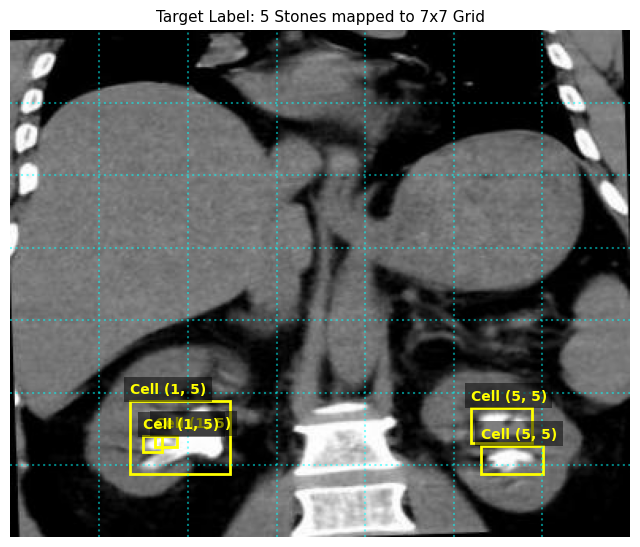

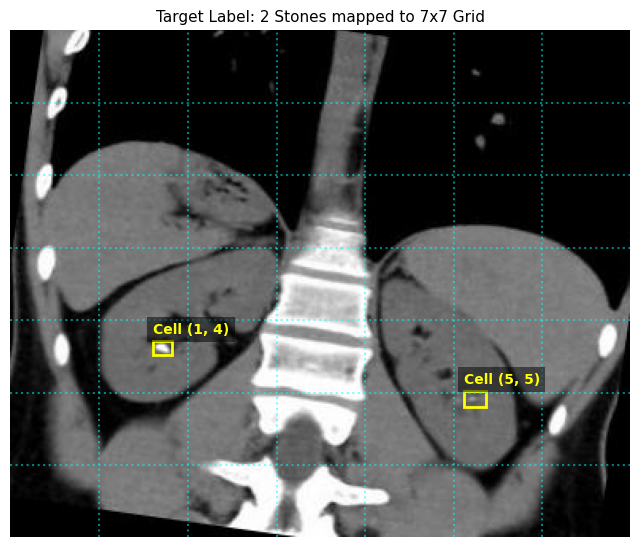

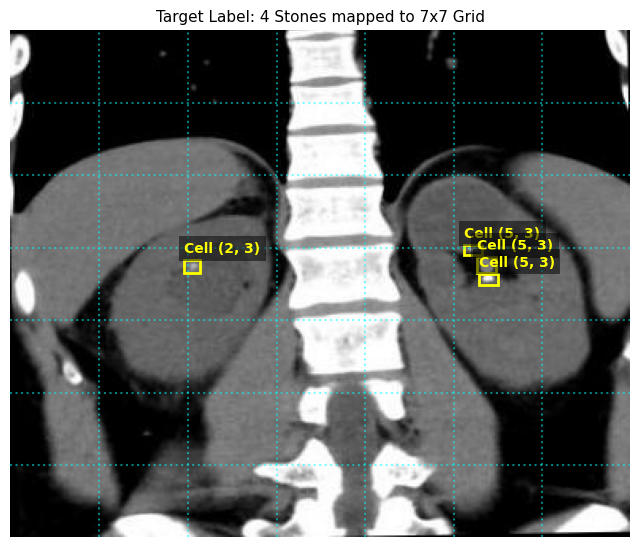

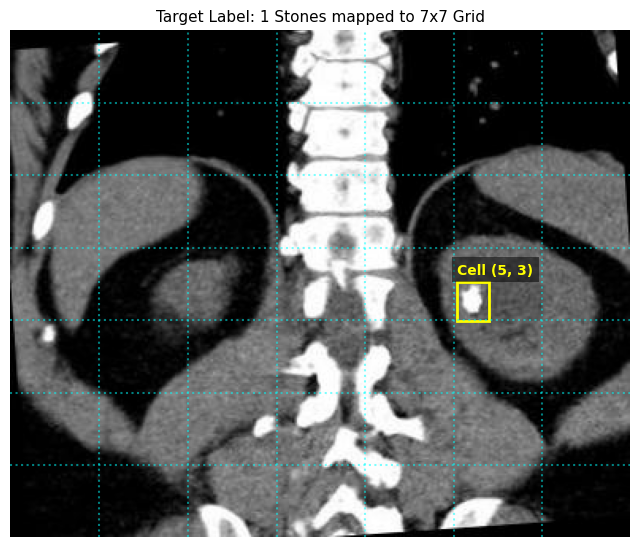

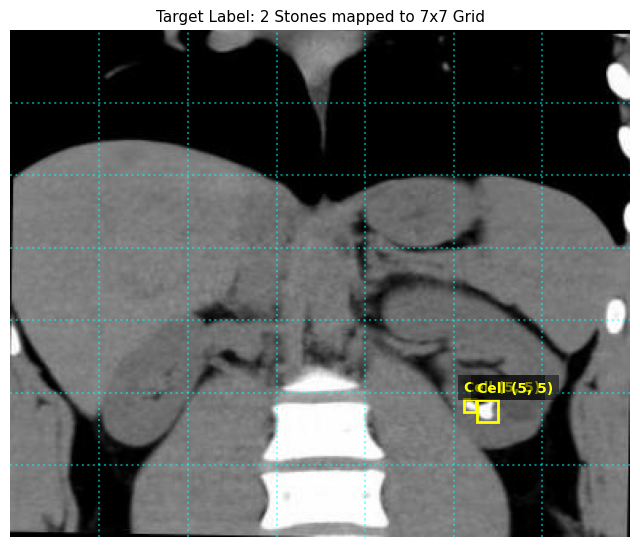

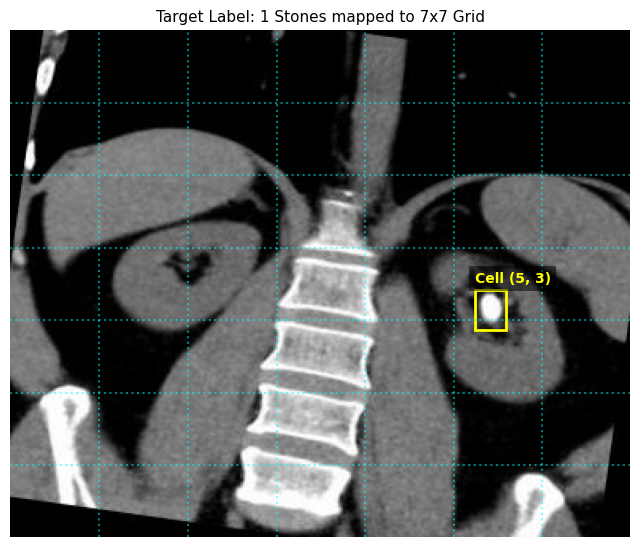

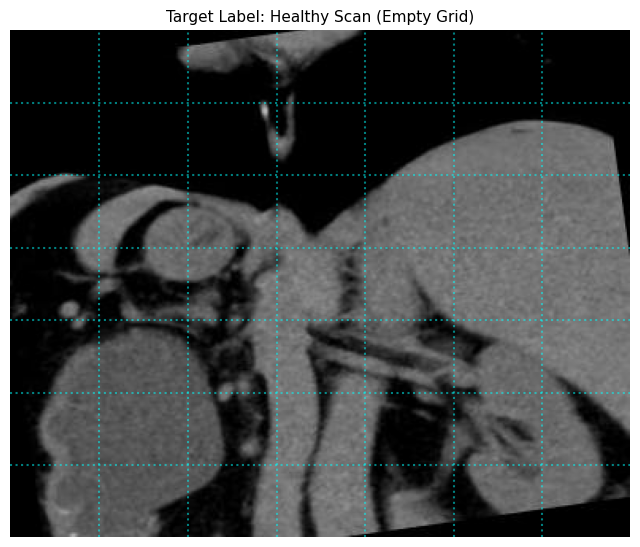

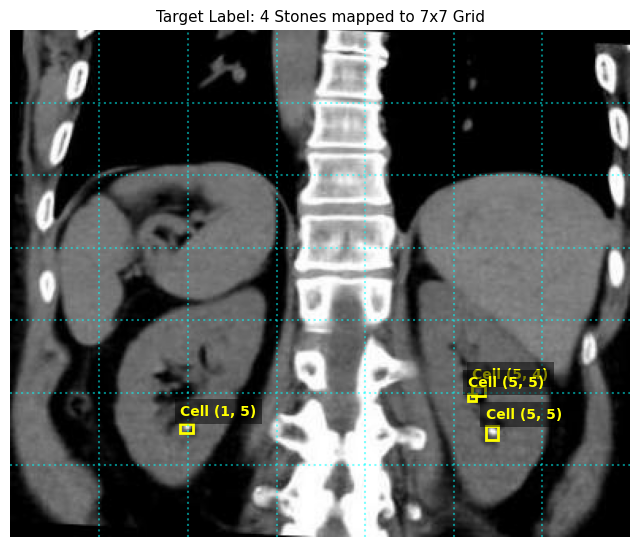

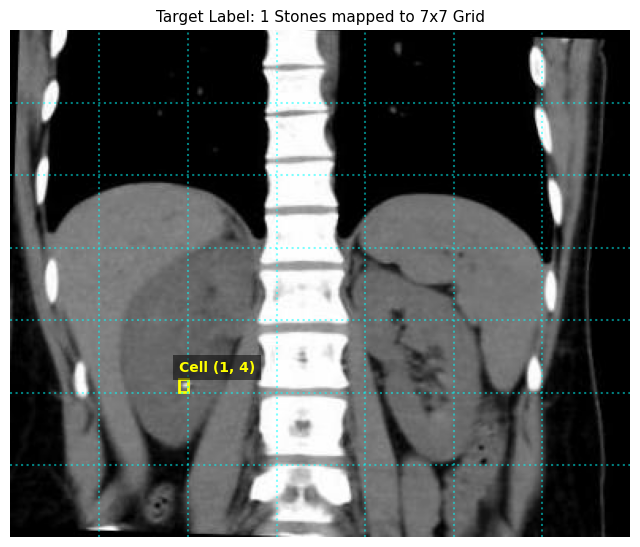

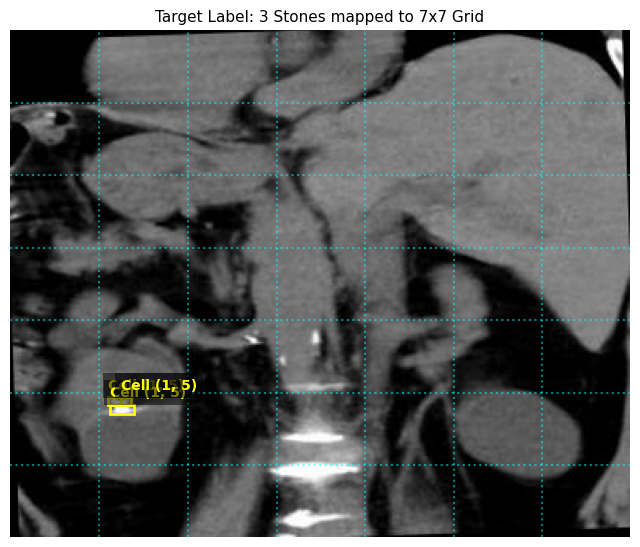

In [11]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def automated_grid_dataset_check(images_dir, labels_dir, num_samples=3, grid_size=7):
    """
    Randomly selects and visualizes images, overlays a 7x7 grid, 
    and shows which specific grid cell is responsible for each stone.
    """
    # 1. Grab every image file in the folder
    all_images = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    if not all_images:
        print(f"No images found in {images_dir}")
        return

    # 2. Pick a random subset to check
    random_samples = random.sample(all_images, min(num_samples, len(all_images)))
    print(f"Scanning {len(random_samples)} random files...\n")
    
    # 3. Loop through the randomly selected images
    for img_name in random_samples:
        img_path = os.path.join(images_dir, img_name)
        
        # Construct the matching label path automatically
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(labels_dir, txt_name)
        
        # Load the image
        img = Image.open(img_path).convert('RGB')
        img_width, img_height = img.size
        
        # Setup plotting
        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(img)
        
        # Draw the 7x7 Grid overlay for visual reference
        cell_w = img_width / grid_size
        cell_h = img_height / grid_size
        for i in range(1, grid_size):
            # Vertical lines
            ax.axvline(x=i * cell_w, color='cyan', linestyle=':', alpha=0.5)
            # Horizontal lines
            ax.axhline(y=i * cell_h, color='cyan', linestyle=':', alpha=0.5)
        
        stones_found = 0
        
        # Read the label file if it exists and isn't empty
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        stones_found += 1
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        # Calculate absolute pixel coordinates
                        w = w_norm * img_width
                        h = h_norm * img_height
                        x_min = (x_c * img_width) - (w / 2)
                        y_min = (y_c * img_height) - (h / 2)
                        
                        # Calculate the Grid Cell index (0-6)
                        grid_x = min(int(x_c * grid_size), grid_size - 1)
                        grid_y = min(int(y_c * grid_size), grid_size - 1)
                        
                        # Draw the bounding box
                        rect = patches.Rectangle((x_min, y_min), w, h, 
                                                 linewidth=2, edgecolor='yellow', facecolor='none')
                        ax.add_patch(rect)
                        
                        # Label the stone with its assigned Grid Cell
                        plt.text(x_min, y_min - 5, f'Cell ({grid_x}, {grid_y})', 
                                 color='yellow', fontsize=10, weight='bold', 
                                 bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
                        
                        # Removed the 'break' statement so it loads ALL stones

        plt.axis('off')
        
        # Give each plot a clean title
        if stones_found > 0:
            plt.title(f"Target Label: {stones_found} Stones mapped to {grid_size}x{grid_size} Grid", fontsize=11)
        else:
            plt.title(f"Target Label: Healthy Scan (Empty Grid)", fontsize=11)
            
        plt.show()

# --- Automated Usage ---
base_dir = 'C:/Users/paulw/OneDrive/Desktop/BME 450/archive'

automated_grid_dataset_check(
    images_dir=f'{base_dir}/train/images', 
    labels_dir=f'{base_dir}/train/labels', 
    num_samples=10
)